In [1]:
from pyuvdata import UVData, UVBeam, utils as uvutils
import numpy as np
import hdf5plugin
import copy
import uvtools as uvt
import matplotlib.pyplot as plt
import hera_cal as hc
# import healvis
from scipy.signal import windows

import astropy.io.fits as fits
import pandas as pd
import h5py
from hera_cal import io, utils, redcal, apply_cal, datacontainer, abscal
import glob
import os
from scipy import stats
import hera_pspec as hp
import astropy
from astropy.time import Time
from astropy.coordinates import get_sun
import astropy.units as u

In [2]:
t = Time("2024-12-05 2:27:24.3", scale="utc")

# Get Sun position (GCRS frame by default)
sun = get_sun(t)

# Convert to ICRS for RA/Dec
sun_icrs = sun.icrs

print(f"RA  = {sun_icrs.ra.to(u.hourangle):.2f}")
print(f"Dec = {sun_icrs.dec.to(u.deg):.2f}")

RA  = 14.48 hourangle
Dec = -13.22 deg


In [3]:
import glob
import re
path_data="/net/sinatra/vault-ike/ntsikelelo/Data_H6C/"
path_data2="/net/sinatra/vault2/ntsikelelo/Data_H6C/"
def numerical_sort(value):
    # Find all digit groups and convert them to integers
    numbers = re.findall(r'\d+', value)
    return list(map(int, numbers)) if numbers else [0]

uvh5name = sorted(glob.glob(path_data2+"*sum.uvh5"), key=numerical_sort)
# files_diff=files = sorted(glob.glob(path_data+"*diff.uvh5"), key=numerical_sort)

In [4]:
uvh5name[4*275]

'/net/sinatra/vault2/ntsikelelo/Data_H6C/zen.2459861.49903.sum.uvh5'

In [5]:
Model_complete_file = uvh5name[0]
uvd1 = UVData()
uvd1.read(Model_complete_file, read_data=False)  
pol=uvd1.polarization_array[0]
uvd1.read(Model_complete_file, polarizations=pol) 
antpos=uvd1.antenna_positions
ants=uvd1.antenna_numbers
antpos_d = dict(zip(ants, antpos))

#make redundant groups model        
reds = hc.redcal.get_pos_reds(antpos_d, include_autos=True)

In [6]:

filter_name="Main_lobe_20_mHz"
filter_name_2="Notch_filter_40_mHz"
filter_name_3="Notch_filter_80_mHz"
filter_name_4="Main_lobe_baseline_dependent"
filter_name_5="Notch_filter_20_mHz"
lst="0h"
spw="low"

In [7]:
Model_complete_file = uvh5name[0]
uvd1 = UVData()
uvd1.read("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/Full_LST_gleam_model_final_"+lst+"_"+spw+".uvh5", read_data=False)
lsts=np.rad2deg(np.unique(uvd1.lst_array))*(24/360)
freqs = uvd1.freq_array*1e-6
dt=((lsts[1]-lsts[0])*60*60)/4
# t_total=(800*dt)/2
# t_total/3600

antenna_diameters are not set or are being overwritten. antenna_diameters are set using values from known telescopes for HERA.


In [11]:
hd = io.HERAData(uvh5name[0])
# antpos, ants = hd.get_ENU_antpos(pick_data_ants=True)
# antpos_d = dict(zip(ants, antpos))
reds = redcal.get_reds(hd.data_antpos, pols=['nn'], pol_mode='1pol')

In [13]:
lsts[65], lsts[65+28]

(np.float64(1.4140386962081983), np.float64(2.0169803298040803))

## Gain analysis

In [14]:
filter_name, filter_name_2, N

('Main_lobe_20_mHz', 'Notch_filter_40_mHz', 28)

In [15]:
gains_gleam.shape

NameError: name 'gains_gleam' is not defined

In [46]:
def mean_sigma(gains):
    sigm_f=[]
    for i in range (205):
        g=stats.stats.gstd(gains[:,i])
        if not np.isnan(g):
            sigm_f.append(g)
    return np.ma.mean(np.ma.array(sigm_f))        

In [53]:
def mean_of_mean(gains):
    sigm_f=[]
    for i in range (205):
        g=np.mean(gains[:,i])
        if not np.isnan(g):
            sigm_f.append(g)
    return np.ma.mean(np.ma.array(sigm_f))  

In [55]:
g1=mean_sigma(gains_gleam)
g2=mean_sigma(gains_full)
g3=mean_sigma(gains_gleam_filter)


Please import `gstd` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.


In [56]:
g1,g2,g3

(np.float64(1.7325836008990005),
 np.float64(1.749235663782134),
 np.float64(1.7766792148947324))

In [57]:
m1=mean_of_mean(gains_gleam)
m2=mean_of_mean(gains_full)
m3=mean_of_mean(gains_gleam_filter)

In [58]:
m1, m2, m3

(np.float64(0.25169530205034363),
 np.float64(0.2467765895372489),
 np.float64(0.45220621096175745))

Text(0, 0.5, '|g|')

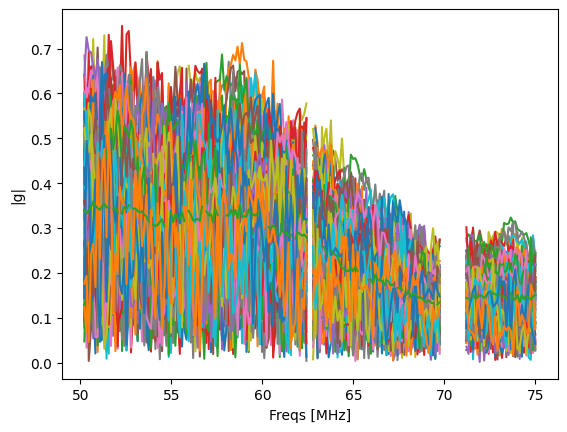

In [12]:
x,y=0,205
for i in range (gains_gleam.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_gleam[i,x:y]))

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam[:,x:y]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

Text(0, 0.5, '|g|')

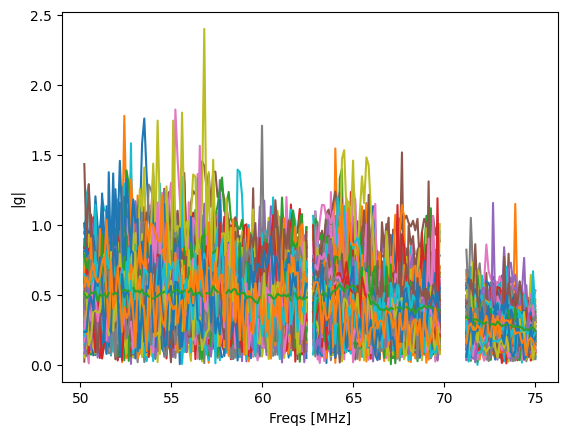

In [52]:
x,y=0,205
for i in range (gains_gleam.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_gleam_filter_notch[i,x:y]))

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam_filter_notch[:,x:y]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

In [53]:


def extract_antenna_gains_all_times(gain_name="gains/gains_gleam_flagged_abscal", N=N,uvh5name=uvh5name):
    gains_gleam =[]
    for i in range (N):
        g1=np.load(path_data+gain_name+uvh5name[i]+".npy",allow_pickle=True).item()
        
        for ant in g1:
            gain_temp=[]
            for t in range (2):
                gain_temp.append(g1[ant][t,:])
            gain_temp=np.array(gain_temp)
            gains_gleam.append(np.mean(gain_temp,axis=0))
    gains_gleam=np.array(gains_gleam) 

    return gains_gleam    

def produce_plots_every_n_time(n=10, N=N, gains=""):
    for m in range (int(N/n)):
        for i in range (N):
        
            if n*m<=i and i<(m+1)*n:
                if i==m*n:
                    plt.figure(figsize=(5,2))
                plt.plot(freqs[50:-1],gains[i,:][50:-1])
                plt.xlabel("Freqs [MHz]")
                plt.ylabel("|g|")

def produce_plots_colour_every_n_time(n=10, N=N, gains=""):
    cl_al=[c['color'] for c in plt.rcParams['axes.prop_cycle']]
    for m in range (int(N/n)):
        for i in range (N):
        
            if n*m<=i and i<(m+1)*n:
                if i==m*n:
                    #plt.figure(figsize=(5,2))
                    cl=cl_al[m]
                plt.plot(freqs[50:-1],gains[i,:][50:-1], cl)
                plt.xlabel("Freqs [MHz]")
                plt.ylabel("|g|")                
        
def produce_average_plots_every_n_time(n=10, N=N, gains="", lsts=lsts):
    for m in range (int(N/n)):
        gain_temp=[]
        for i in range (N):
            
            if n*m<=i and i<(m+1)*n:
                
                if i==m*n:
                    gain_temp.append(gains[i,:][50:-1])
        gain_temp=np.array(gain_temp)
        gains_ave=np.mean(gain_temp, axis=0)
                
        plt.plot(freqs[50:-1],gains_ave, label="lst ="+str(np.round(lsts[m*n],2)))    
        plt.xlabel("Freqs [MHz]")
        plt.ylabel("|g|")
        plt.legend()

# Extract gains

## Plots gains every 10*20s

In [54]:
# produce_plots_every_n_time(n=10, N=N, gains=gains_gleam)

In [55]:

# produce_plots_every_n_time(n=10, N=N, gains=gains_gleam_filter)

In [56]:
# produce_plots_every_n_time(n=10, N=N, gains=gains_full)

In [57]:
# produce_plots_every_n_time(n=10, N=N, gains=gains_full_filter)

## Plot average over with colour

In [58]:
plt.figure(figsize=(5,2))
produce_plots_colour_every_n_time(n=20, N=N-20, gains=gains_gleam)
plt.figure(figsize=(5,2))
produce_plots_colour_every_n_time(n=20, N=N-20, gains=gains_gleam_filter_notch)
plt.figure(figsize=(5,2))
produce_plots_colour_every_n_time(n=20, N=N-20, gains=gains_full_filter_notch)
plt.figure(figsize=(5,2))
produce_plots_colour_every_n_time(n=20, N=N-20, gains=gains_full)

<Figure size 500x200 with 0 Axes>

<Figure size 500x200 with 0 Axes>

<Figure size 500x200 with 0 Axes>

<Figure size 500x200 with 0 Axes>

In [59]:
produce_plots_colour_every_n_time(n=20, N=N-20, gains=gains_full_filter)
plt.figure()
produce_plots_colour_every_n_time(n=20, N=N-20, gains=gains_gleam_filter)

<Figure size 640x480 with 0 Axes>

## Average gains over 10n

In [60]:
plt.figure(figsize=(25,15))
produce_average_plots_every_n_time(n=10, N=N-20, gains=gains_gleam, lsts=lsts)

# plt.figure(figsize=(5,2))
# produce_average_plots_every_n_time(n=10, N=N, gains=gains_gleam_filter, lsts=lsts)

# plt.figure(figsize=(5,2))
# produce_average_plots_every_n_time(n=10, N=N, gains=gains_full, lsts=lsts)

# plt.figure(figsize=(5,2))
# produce_average_plots_every_n_time(n=10, N=N, gains=gains_gleam_filter, lsts=lsts)

<Figure size 2500x1500 with 0 Axes>

In [61]:

plt.figure(figsize=(20,10))
produce_average_plots_every_n_time(n=10, N=N-20, gains=gains_gleam_filter, lsts=lsts)

<Figure size 2000x1000 with 0 Axes>

# Subset of freqs

Text(0, 0.5, '|g|')

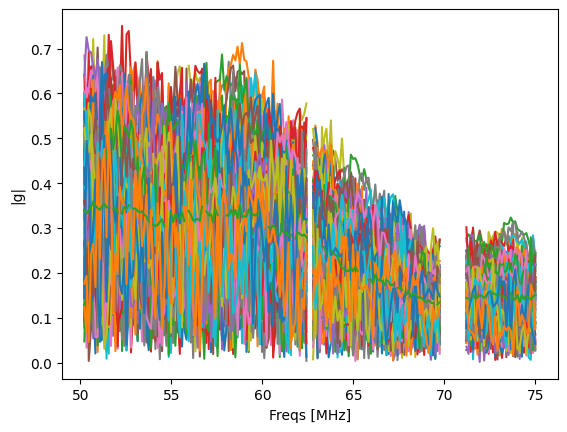

In [62]:
x,y=0,205
for i in range (gains_gleam.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_gleam[i,x:y]))

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam[:,x:y]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

In [63]:
len(gains_gleam)


112

Text(0, 0.5, '|g|')

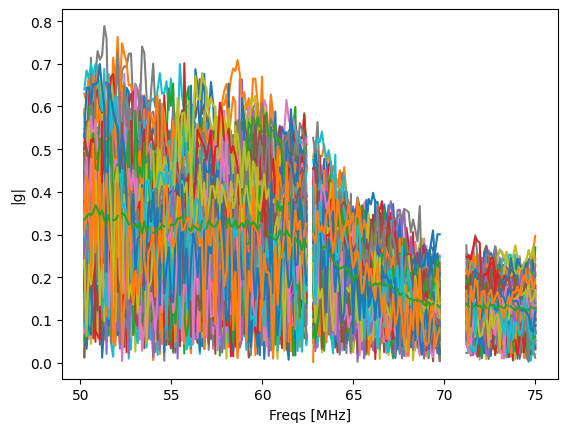

In [64]:

for i in range (gains_full.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_full[i,x:y]))

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_full[:,x:y]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

Text(0, 0.5, '|g|')

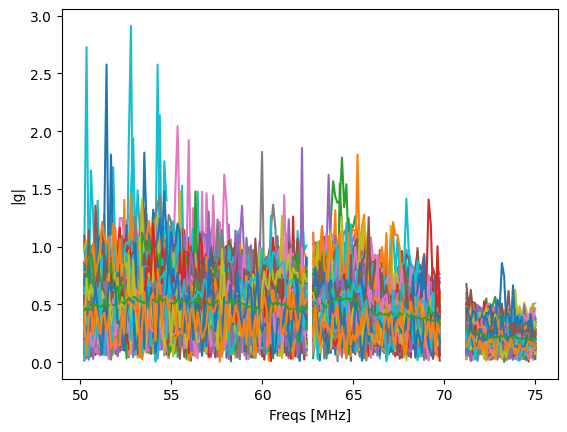

In [65]:

for i in range (gains_full_filter.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_full_filter_notch[i,x:y]))

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_full_filter_notch[:,x:y]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

Text(0, 0.5, '|g|')

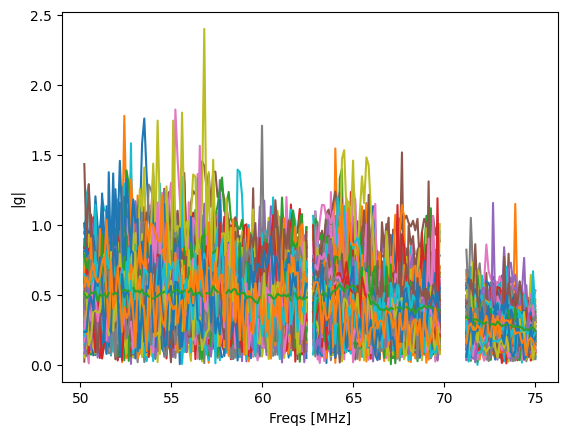

In [66]:

for i in range (gains_gleam_filter.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_gleam_filter_notch[i,x:y]))

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam_filter_notch[:,x:y]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

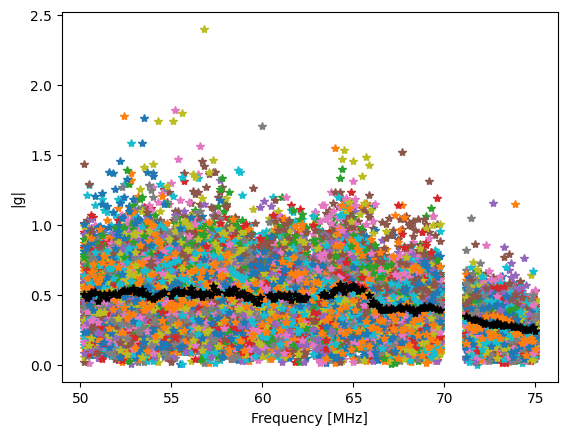

In [67]:
for i in range (gains_gleam_filter.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_gleam_filter[i,x:y]),'*')

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam_filter[:,x:y]), axis=0)),'k*')  
plt.xlabel("Frequency [MHz]")
plt.ylabel("|g|")
plt.savefig("paper_figures/gains_notch.pdf")

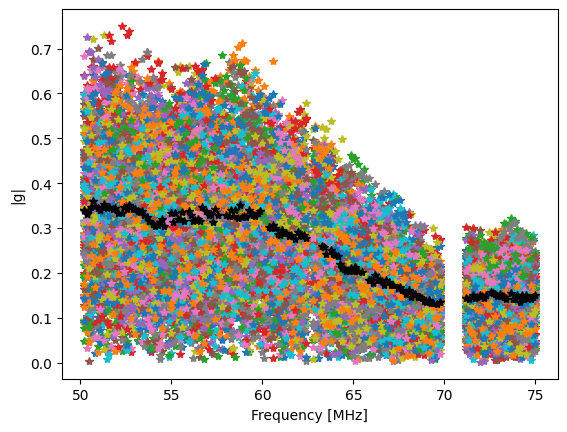

In [68]:
for i in range (gains_gleam_filter.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_gleam[i,x:y]),'*')

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam[:,x:y]), axis=0)),'k*')  
plt.xlabel("Frequency [MHz]")
plt.ylabel("|g|")
plt.savefig("paper_figures/gains_no_filter_gleam.pdf")

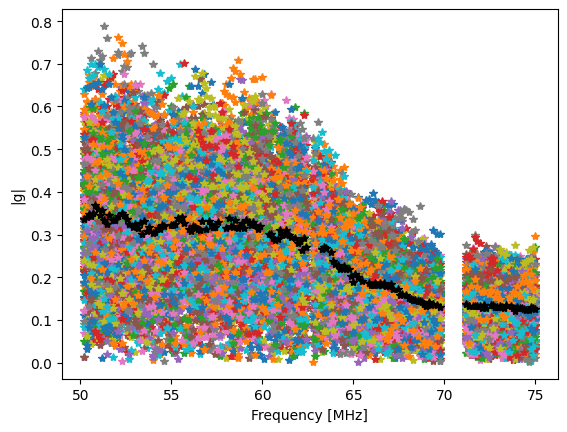

In [69]:
for i in range (gains_gleam_filter.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_full[i,x:y]),'*')

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_full[:,x:y]), axis=0)),'k*')  
plt.xlabel("Frequency [MHz]")
plt.ylabel("|g|")
plt.savefig("paper_figures/gains_no_filter_full.pdf")

Text(0, 0.5, '|g|')

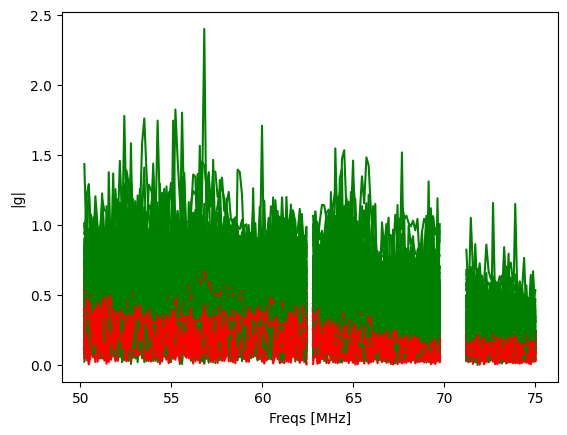

In [70]:

for i in range (gains_gleam_filter.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_gleam_filter_notch[i,x:y]), 'g')
    plt.plot(freqs[x:y],np.abs(gains_gleam[i,x:y]), 'r')

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam_filter_notch[:,x:y]), axis=0)),'g')  
plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam[:,x:y]), axis=0)),'r')  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

## Avarage gain amplitude

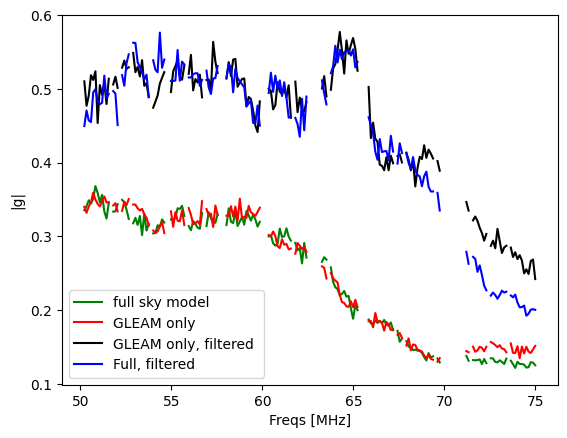

In [71]:
plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_full[:,x:y]), axis=0)),'g', label="full sky model") 
plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam[:,x:y]), axis=0)),'r', label="GLEAM only") 
plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam_filter_notch[:,x:y]), axis=0)),'k', label="GLEAM only, filtered ") 
plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_full_filter_notch[:,x:y]), axis=0)),'b', label="Full, filtered ") 
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")
plt.legend()

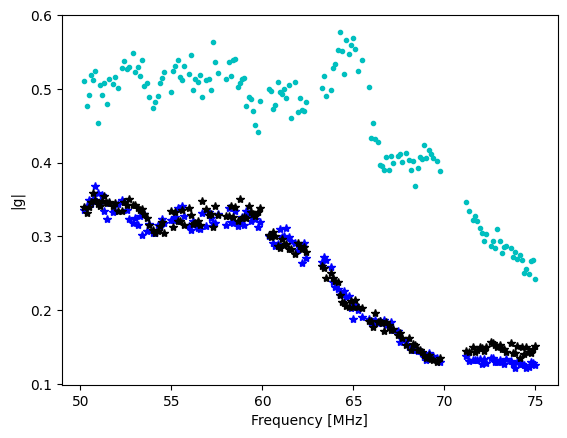

In [49]:
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam_filter_notch), axis=0)),'c.', label="gleam, notch") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_full), axis=0)),'b*', label="GLEAM only") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam), axis=0)),'k*', label="gleam, mainlobe ") 
# plt.plot(freqs,np.abs(np.mean(np.abs(gains_full_filter_notch), axis=0)),'y.', label="Full, filtered ") 
plt.xlabel("Frequency [MHz]")
plt.ylabel("|g|")
plt.savefig("paper_figures/gains_average_notch_filter.pdf")

In [52]:
np.mean(np.abs(np.mean(np.abs(gains_gleam_filter_notch)))), np.mean(np.abs(np.mean(np.abs(gains_full), axis=0))), np.mean(np.abs(np.mean(np.abs(gains_gleam), axis=0)))

(np.float64(nan), np.float64(nan), np.float64(nan))

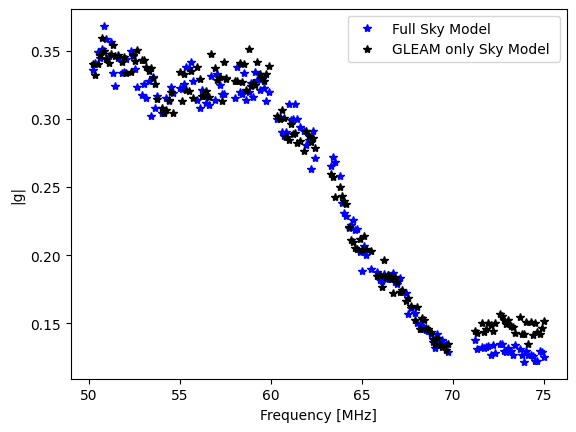

In [73]:
# plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam_filter_notch), axis=0)),'c.', label="gleam, notch") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_full), axis=0)),'b*', label="Full Sky Model") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam), axis=0)),'k*', label="GLEAM only Sky Model ") 
# plt.plot(freqs,np.abs(np.mean(np.abs(gains_full_filter_notch), axis=0)),'y.', label="Full, filtered ") 
plt.xlabel("Frequency [MHz]")
plt.ylabel("|g|")
plt.legend()
plt.savefig("paper_figures/gains_average_no_filter.pdf")

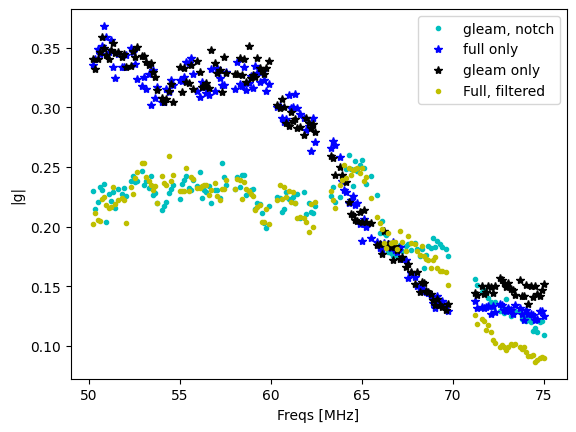

In [74]:
c=0.45
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam_filter_notch), axis=0))*c,'c.', label="gleam, notch") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_full), axis=0)),'b*', label="full only") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam), axis=0)),'k*', label="gleam only ") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_full_filter_notch), axis=0))*c,'y.', label="Full, filtered ") 
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")
plt.legend()

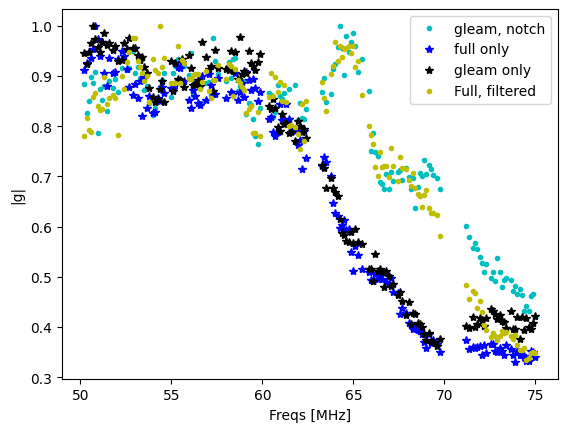

In [75]:
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam_filter_notch), axis=0))/np.nanmax(np.abs(np.mean(np.abs(gains_gleam_filter_notch), axis=0))),'c.', label="gleam, notch") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_full), axis=0))/np.nanmax(np.abs(np.mean(np.abs(gains_full), axis=0))),'b*', label="full only") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam), axis=0))/np.nanmax(np.abs(np.mean(np.abs(gains_gleam), axis=0))),'k*', label="gleam only ") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_full_filter_notch), axis=0))/np.nanmax(np.abs(np.mean(np.abs(gains_full_filter_notch), axis=0))),'y.', label="Full, filtered ") 
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")
plt.legend()

## Delay Transform average gain

In [76]:
def fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=""):

    gains=np.abs(gains_raw)
    tau=np.fft.fftshift(np.fft.fftfreq(len(freqs),np.abs(freqs[1]-freqs[0])))*1e3
    index=np.where(tau>=0)
    tau_pos=tau[index]
    window=np.ones(gains.shape)
    for i in range(window.shape[0]):
        window[i,:]=windows.blackmanharris(len(freqs))
    
   
    gains_full_fitted=[]
    for t in range (gains.shape[0]):
        gains_time_no_nans=gains[t,:][~np.isnan(gains[t,:])]
        freq_no_nans=freqs[~np.isnan(gains[t,:])]
        coeffs = np.polyfit(freq_no_nans, gains_time_no_nans, 6)
        poly = np.poly1d(coeffs)
        x_fit=freqs
        y_fit=poly(x_fit)
        gains_fitted=[]
        for i in range (gains.shape[1]):
            if np.isnan(gains[t,i]):
                gains_fitted.append(poly(x_fit[i]))
            else:
                gains_fitted.append(gains[t,i])
        gains_fitted=np.array(gains_fitted)

        gains_full_fitted.append(gains_fitted)
    gains_full_fitted=np.array(gains_full_fitted)
    print(gains_full_fitted.shape)
    g0_delay=[]
    for i in range (gains_full_fitted.shape[0]-1):
        g1=np.fft.fftshift(np.abs(np.fft.fft(window*gains_full_fitted)))[i,:]
        g2=np.fft.fftshift(np.abs(np.fft.fft(window*gains_full_fitted)))[i+1,:]
        g0_delay.append(g1*np.conjugate(g2))
    g0_delay=np.array(g0_delay)
    
    g0_delay=np.mean(g0_delay,axis=0)[index]
    
    return np.mean(gains_full_fitted, axis=0), gains_full_fitted,np.abs(g0_delay), tau_pos





In [77]:
def produce_plots_delay(n,N):
    
    x,y=0,205
    gains_full_ave, g0, full_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_full[n:N,x:y])
    gains_gleam_ave, g1, gleam_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_gleam[n:N,x:y])
    gains_gleam_filter_ave, g2, gleam_filter_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_gleam_filter[n:N,x:y])
    gains_full_filter_ave, g3, full_filter_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_full_filter[n:N,x:y])
    gains_full_filter_ave_notch, g4, full_filter_notch_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_full_filter_notch[n:N,x:y])
    gains_gleam_filter_ave_notch, g5, gleam_filter_notch_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_gleam_filter_notch[n:N,x:y])
    
    
    
    # plt.plot(freqs[x:y], gains_full_ave,'k', label="full")
    # plt.plot(freqs[x:y], gains_gleam_ave, 'r', label="gleam")
    # plt.plot(freqs[x:y], gains_gleam_filter_ave, 'g', label="gleam filter")
    # plt.plot(freqs[x:y], gains_full_filter_ave, 'm', label="full filter")
    # plt.plot(freqs[x:y], gains_gleam_filter_ave_notch, 'c', label="notch gleam filter")
    # plt.plot(freqs[x:y], gains_full_filter_ave_notch, 'b', label="notch full filter")
    
    # plt.xlabel("Freq[MHz]")
    # plt.ylabel("$|g(\\nu)|$")
    # plt.legend()
    plt.figure()
    # print(tau_pos, gleam_delay)
    # plt.semilogy(tau_pos, full_delay,'k')
    # plt.semilogy(tau_pos, gleam_delay,'r')
    # plt.semilogy(tau_pos, gleam_filter_delay,'g')
    # plt.semilogy(tau_pos, full_filter_delay,'m')

    plt.semilogy(tau_pos, full_delay/np.max(full_delay),'b')
    plt.semilogy(tau_pos, gleam_delay/np.max(gleam_delay),'k')
    # plt.semilogy(tau_pos, gleam_filter_delay/np.max(gleam_filter_delay),'g')
    # plt.semilogy(tau_pos, full_filter_delay/np.max(full_filter_delay),'m')
    # plt.semilogy(tau_pos, full_filter_notch_delay/np.max(full_filter_notch_delay),'y')
    plt.semilogy(tau_pos, gleam_filter_notch_delay/np.max(gleam_filter_notch_delay),'c')
    plt.xlabel("Delay $\\tau$ [ns]")
    plt.ylabel("$|g(\\tau)|$")
    plt.xlim([0,600])
    plt.savefig("paper_figures/gains_delay_space_notch_filter.pdf")

(112, 205)
(112, 205)
(112, 205)
(112, 205)
(112, 205)
(112, 205)


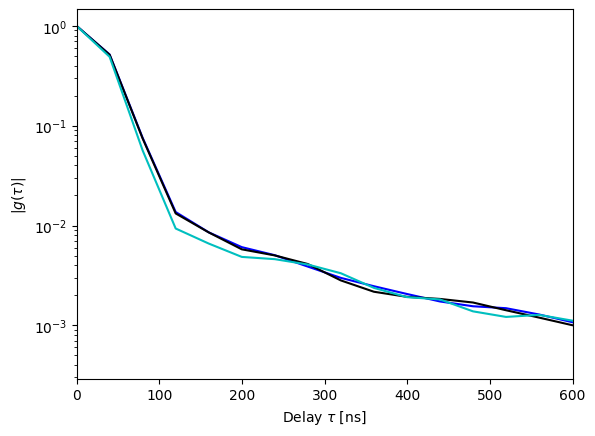

In [78]:
produce_plots_delay(n=0,N=200)

In [ ]:
produce_plots_delay(n=0,N=70)

In [ ]:
produce_plots_delay(n=0,N=len(gains_full))

In [ ]:
produce_plots_delay(n=3,N=250)

In [ ]:
lsts[0]

In [ ]:
lsts[100]

In [ ]:
40*60*100.0

In [ ]:
produce_plots_delay(n=50,N=70)

In [ ]:
produce_plots_delay(n=0,N=100)

In [ ]:
gains_full_ave, g0, full_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_full[90:100,50:-1])
gains_gleam_ave, g1, gleam_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_gleam[90:100,50:-1])
gains_gleam_filter_ave, g2, gleam_filter_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_gleam_filter[90:100,50:-1])
gains_full_filter_ave, g3, full_filter_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_full_filter[90:100,50:-1])


In [ ]:
plt.plot(gains_full_ave,'k')
plt.plot(gains_gleam_ave, 'r')
plt.plot(gains_gleam_filter_ave, 'g')
plt.plot(gains_full_filter_ave)

In [ ]:
plt.semilogy(tau_pos, full_delay,'k')
plt.semilogy(tau_pos, gleam_delay,'r')
plt.semilogy(tau_pos, gleam_filter_delay,'m')
plt.semilogy(tau_pos, full_filter_delay,'g')
# plt.xlim([0,5000])

## Chis-sqaure

In [13]:
N=90
chis_no_filer =[]
for i in range (N):
    i=i+1
    g1=np.load(path_data+"chisq/chisq_redcal_"+uvh5name[i][43:69]+".npy")

    chis_no_filer.append(g1)
chis_no_filer=np.array(chis_no_filer) 

In [15]:
chis_filer =[]
for i in range (N):
    i=i+1
    g1=np.load(path_data+"chisq/chisq_"+filter_name_5+"_redcal_"+uvh5name[i][43:69]+".npy")

    chis_filer.append(g1)
chis_filer=np.array(chis_filer) 

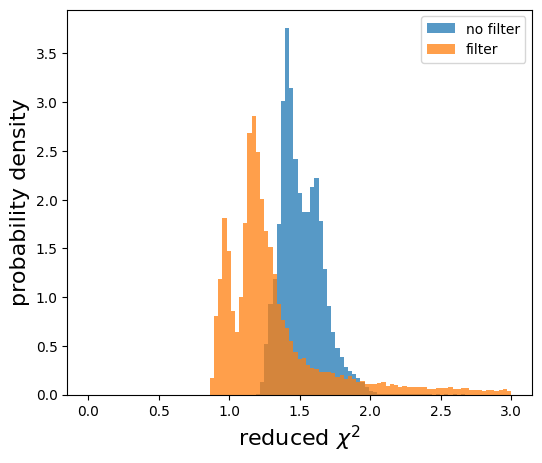

In [28]:
plt.figure(figsize=(6, 5))
plt.hist(np.abs(chis_no_filer.ravel()), bins=101, range=(0, 3), density=True, alpha=0.75,label="no filter")
plt.hist(np.abs(chis_filer.ravel())/0.15, bins=101, range=(0, 3), density=True, alpha=0.75,label="filter")
x = np.linspace(0.8, 1.2, 1000)
#plt.plot(x, stats.chi2.pdf(x * 2*dof, 2*dof) * 2*dof, c='k', ls='--', lw=2,label="$\chi_k^2$ (kx)/k ")
plt.xlabel(r'reduced $\chi^2$', fontsize=16)
plt.ylabel('probability density', fontsize=16)
plt.legend()

In [ ]:
bls_select=[]
for i in range (len(baseline)):
    bls_select.append((baseline[i][0],baseline[i][1]))

In [ ]:
path_data_model="/net/sinatra/vault-ike/ntsikelelo/Model_Data_H6C/"
path_data="/net/sinatra/vault-ike/ntsikelelo/Data_H6C/"

hd= io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/zen.2459861.50015.sum.uvh5")
# hd2 = hc.io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/single_pol_data_combined_2h_test.uvh5")
freqs = hd.freq_array
antpos, ants = hd.get_ENU_antpos(pick_data_ants=True)
antpos_d = dict(zip(ants, antpos))

bl_lens = {bl: np.linalg.norm(antpos_d[bl[1]]-antpos_d[bl[0]]) for bl in hd.get_antpairs()}   
# downselect to maximum baseline length (to reduce computational load in calibration)
bls = []
for bl in list(hd.get_antpairs()):
    # max 40 m baseline cut (also cut autos)
    bl_len = np.linalg.norm(antpos_d[bl[1]] - antpos_d[bl[0]])
    if bl_len > 0:
        bls.append(bl[:2])   

time=np.unique(hd.time_array)[0]
# only load a couple of times and frequencies
pol=hd.polarization_array
hd.read(polarizations=pol[0],frequencies=freqs, times=time)
# hd2.read(polarizations=pol[0],frequencies=freqs,times=time)

# hd.conjugate_bls()
# hd._determine_blt_slicing()
# hd._determine_pol_indexing()

# hd2.conjugate_bls()
# hd2._determine_blt_slicing()
# hd2._determine_pol_indexing()

 
hd.x_orientation = 'east'
# hd2.x_orientation = 'east'

hd.select(bls=bls)
  
    # load datacontainer
data, _, _ = hd.build_datacontainers() #xtalk raw data
# model, _, _ = hd2.build_datacontainers() # x-talk model
   


 



        
        




In [ ]:
pol=hd.polarization_array

In [ ]:
for key in data:
    plt.plot(np.abs(data[key][0,:]))
# plt.plot(np.abs(model[(27, 48, 'ee')][0,0:100]))

In [ ]:
reds = hc.redcal.get_reds(antpos_d, pols=['ee'])
red_data=[]
for red_g in reds:
    bl_group=[]
    for bl in red_g:
        if bl in list(data.keys()):
            bl_group.append(bl)    
    if len(bl_group)>0:   
        red_data.append(bl_group)    

# rc = hc.redcal.RedundantCalibrator(filtered_reds)
rc = hc.redcal.RedundantCalibrator(red_data)


In [ ]:
#get redundant baseline groups in data

Nrms=1e-4

# get noise wgts (use whatever noise RMS you put into the data)
noise_wgts = {k: np.ones_like(data[k], dtype=float) / Nrms**2 for k in data}


#     # perform logcal
logcal_meta, logcal_sol = rc.logcal(data)
hc.redcal.make_sol_finite(logcal_sol)
#remove redcal degeneracies from solution
# logcal_sol = rc.remove_degen(logcal_sol)
#get gains and model visibilities
# logcal_gains, logcal_vis = hc.redcal.get_gains_and_vis_from_sol(logcal_sol)



In [ ]:
#perform omnical (lincal)
conv_crit = 1e-10
maxiter = 500
gain = 0.4
lincal_meta, lincal_sol = rc.omnical(data, logcal_sol, wgts=noise_wgts, conv_crit=conv_crit,
                                 maxiter=maxiter, gain=gain)




In [ ]:
for ant in logcal_sol.gains:

    plt.plot(np.abs(logcal_sol.gains[ant])[0])

In [ ]:
for ant in lincal_sol.gains:

    plt.plot(np.abs(lincal_sol.gains[ant])[0])

In [ ]:
for ant in lincal_sol.vis:

    plt.plot(np.abs(lincal_sol.vis[ant])[0])

In [ ]:
# figure out appropriate model times to load
matched_model_files=["/net/sinatra/vault-ike/ntsikelelo/Model_Data_H6C/single_pol_model_combined_2h_test.uvh5"]
hdm = io.HERAData(matched_model_files)
times=np.unique(hdm.time_array)
hdm.read(polarizations=pol[0], times=times[0], frequencies=freqs)
model_data,_,_=hdm.build_datacontainers() 


In [ ]:
data_bls, model_bls, data_to_model_bl_map=abscal.match_baselines(data_bls=data.keys(), model_bls=model_data.keys(), data_antpos=data.antpos,model_antpos= model_data.antpos, pols=['nn'], data_is_redsol=True,
    model_is_redundant=True, verbose=True)

In [ ]:
model_data_modi=copy.deepcopy(data)
for i in range (len(model_bls)):
    model_data_modi[data_bls[i]]=model_data[model_bls[i]]


In [ ]:
model_data_modi[data_bls[0]]


In [ ]:
model_data[model_bls[0]]

In [ ]:
# calibration with lincal gains
redcal_data = copy.deepcopy(data)
hc.apply_cal.calibrate_in_place(redcal_data, lincal_sol.gains)

In [ ]:
for key in redcal_data:
    if key in data_bls:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(redcal_data[key][0,:]))
# plt.plot(np.abs(model[(27, 48, 'ee')][0,0:100]))

In [ ]:
# calibration with lincal gains
calibrated_data = copy.deepcopy(redcal_data)

In [ ]:
rc_flags = {k: np.zeros_like(lincal_sol.gains[k], dtype=bool) for k in lincal_sol.gains}


In [ ]:
noise_wgts = {k: np.ones_like(redcal_data[k], dtype=float)  for k in redcal_data}

for k in data:

    if k not in data_bls: 

        noise_wgts[k] = np.ones(noise_wgts[k].shape)*1e-40


In [ ]:
abscal_gains = hc.abscal.post_redcal_abscal(model_data_modi, calibrated_data, noise_wgts, rc_flags, verbose=False)

In [ ]:
total_gains = hc.abscal.merge_gains([lincal_sol.gains, abscal_gains])

In [ ]:
for ant in total_gains:

    plt.plot(np.abs(abscal_gains[ant])[0])

In [ ]:
for ant in total_gains:

    plt.plot(np.abs(total_gains[ant])[0])

In [ ]:
for key in redcal_data:
    if key in data_bls:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(calibrated_data[key][0,:]))
# plt.plot(np.abs(model[(27, 48, 'ee')][0,0:100]))

In [ ]:
hc.abscal.post_redcal_abscal??